# Quantum vs Classical SVM on PBMC Single-Cell RNA Sequencing Data

## Overview

This notebook benchmarks **Classical SVMs**, **Quantum Kernel SVMs**, and a simplified **Quantum Oracle Sketching (QOS)** approach on the PBMC3k dataset — the same real-world dataset used in *Zhao et al. (2026)* to validate exponential quantum advantage in classical data processing.

### What is PBMC3k?

PBMC stands for **Peripheral Blood Mononuclear Cells**. The PBMC3k dataset contains ~3,000 human blood cells sequenced with 10x Genomics Chromium, each described by the expression levels of ~33,000 genes. These cells belong to distinct biological types (T cells, B cells, NK cells, Monocytes, etc.) identified by clustering.

This dataset is an ideal QML benchmark because:
- It has **genuine biological noise** (technical dropout, batch effects, sequencing variability)
- It is **high-dimensional** (33k genes → requires aggressive dimensionality reduction)
- It has **8 biologically meaningful classes** with varying separability
- It is the **exact dataset** from the quantum advantage paper by Zhao et al.


### Kernel Methods and Quantum Advantage

SVMs with kernel methods avoid the **Barren Plateau** problem that plagues QNNs, since kernels don't use gradients. The quantum kernel projects data into a **2ⁿ-dimensional Hilbert space** (256 dimensions with 8 qubits), making it possible to find hyperplanes that separate complex biological relationships.

The **IQPEmbedding** (Instantaneous Quantum Polynomial) creates entanglement between features via ZZ interactions, which is the key difference from a simple angle embedding — it captures feature correlations of higher order that classical RBF kernels cannot replicate efficiently.

With 8 qubits and `n_repeats=3`, the circuit has ~216 gates per encoding, projecting each data point into a 256-dimensional Hilbert space with third-order feature correlations.

## 1. Imports and Setup

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import os
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

import scanpy as sc
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import pennylane as qml
from pennylane import numpy as pnp

sc.settings.verbosity = 1
np.random.seed(42)

## 2. Load and Explore the PBMC3k Dataset

The PBMC3k dataset is loaded via `scanpy`. On the **first run**, it downloads the raw data from 10x Genomics servers (~6 MB), runs the full preprocessing pipeline (normalization, HVG selection, PCA, Leiden clustering), and saves a clean local copy to `data/pbmc3k_preprocessed.h5ad`.

On **subsequent runs**, the notebook loads directly from the local `.h5ad` file — no internet connection needed.

**Preprocessing steps applied:**
- Filter cells with <200 genes and genes expressed in <3 cells
- Remove cells with >5% mitochondrial reads (dying cells) or >2500 genes (doublets)
- Normalize total counts per cell to 10,000
- Log1p transform: `X = log(X + 1)`
- Select top 2000 highly variable genes (HVGs)
- Scale to zero mean, unit variance
- Leiden clustering (resolution=0.9) → 8 annotated cell types

> **Note on Louvain vs Leiden**: `louvain` does not compile on Python 3.12+. `leidenalg` is its modern replacement — install with `pip install leidenalg`.

In [29]:
# Local cache configuration
DATA_DIR   = "data"
CACHE_PATH = os.path.join(DATA_DIR, "pbmc3k_preprocessed.h5ad")
os.makedirs(DATA_DIR, exist_ok=True)

# Load or download + preprocess
if os.path.exists(CACHE_PATH):
    print(f"✓ Local cache found at '{CACHE_PATH}' — loading directly.")
    adata = sc.read_h5ad(CACHE_PATH)
    print(f"  Loaded {adata.n_obs} cells × {adata.n_vars} genes")

else:
    print("No local cache found. Downloading and preprocessing PBMC3k...")
    print("(This runs once and saves a local copy — subsequent runs are instant)\n")

    # Step 1: Download raw PBMC3k from 10x Genomics via scanpy
    print("[1/6] Downloading raw data (~6 MB)...")
    adata = sc.datasets.pbmc3k()
    print(f"      Raw data: {adata.n_obs} cells × {adata.n_vars} genes")

    # Step 2: Basic quality filtering
    print("[2/6] Filtering low-quality cells and genes...")
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)

    # Flag mitochondrial genes (high mt% = dying cells)
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
    )
    adata = adata[adata.obs.pct_counts_mt < 5, :]
    adata = adata[adata.obs.n_genes_by_counts < 2500, :]
    print(f"      After filtering: {adata.n_obs} cells × {adata.n_vars} genes")

    # Step 3: Normalization and log transform
    print("[3/6] Normalizing and log-transforming...")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # Step 4: Highly variable genes
    print("[4/6] Selecting 2000 highly variable genes...")
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata = adata[:, adata.var.highly_variable]
    sc.pp.scale(adata, max_value=10)
    print(f"      Retained {adata.n_vars} HVGs")

    # Step 5: PCA + neighborhood graph + Leiden clustering
    # Leiden is the modern successor to Louvain — compatible with Python 3.12+.
    # resolution=0.9 reliably produces 8 clusters on PBMC3k.
    print("[5/6] Running PCA, neighborhood graph, and Leiden clustering...")
    sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.9)

    # Step 6: Annotate clusters with known cell types
    # Standard PBMC3k marker-based annotation.
    print("[6/6] Annotating clusters with cell type markers...")
    cell_type_map = {
        '0': 'CD4 T cells',
        '1': 'CD14 Monocytes',
        '2': 'B cells',
        '3': 'CD8 T cells',
        '4': 'NK cells',
        '5': 'FCGR3A Monocytes',
        '6': 'Dendritic cells',
        '7': 'Megakaryocytes',
    }
    adata.obs['cell_type'] = adata.obs['leiden'].map(
        lambda x: cell_type_map.get(x, f'Cluster {x}')
    )

    # ── Save preprocessed data locally ─────────────────────────────────────
    adata.write_h5ad(CACHE_PATH)
    print(f"\n✓ Preprocessed data saved to '{CACHE_PATH}'")
    print(f"  Final dataset: {adata.n_obs} cells × {adata.n_vars} genes")

# ── Use 'cell_type' if available, else fall back to 'leiden' ───────────────
label_col = 'cell_type' if 'cell_type' in adata.obs.columns else 'leiden'

print(f"\n=== PBMC3k Dataset Overview ===")
print(f"Total cells : {adata.n_obs}")
print(f"Total genes : {adata.n_vars}")
print(f"Label column: '{label_col}'")
print(f"\nCell type distribution:")
print(adata.obs[label_col].value_counts())

✓ Local cache found at 'data/pbmc3k_preprocessed.h5ad' — loading directly.
  Loaded 2638 cells × 1838 genes

=== PBMC3k Dataset Overview ===
Total cells : 2638
Total genes : 1838
Label column: 'cell_type'

Cell type distribution:
cell_type
CD4 T cells         1152
CD14 Monocytes       422
B cells              341
CD8 T cells          302
NK cells             217
FCGR3A Monocytes     155
Dendritic cells       36
Megakaryocytes        13
Name: count, dtype: int64


### 2.1 Stratified Subsampling — 1500 Cells, 8 Classes

We subsample 1500 cells using stratified sampling to preserve the relative proportions of each cell type

In [30]:
# Extract gene expression matrix and labels
X_full = adata.X
if hasattr(X_full, 'toarray'):
    X_full = X_full.toarray()

labels_full = adata.obs[label_col].values
le = LabelEncoder()
y_full = le.fit_transform(labels_full)
class_names = le.classes_
n_classes = len(class_names)

print(f"Number of classes: {n_classes}")
print(f"Class names: {class_names.tolist()}")

# Stratified subsample: 1500 cells
N_SAMPLES = 1500
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SAMPLES, random_state=42)
subsample_idx, _ = next(sss.split(X_full, y_full))

X_sub = X_full[subsample_idx]
y_sub = y_full[subsample_idx]

print(f"\nSubsample shape: {X_sub.shape}")
print(f"\nSubsample class distribution:")
unique, counts = np.unique(y_sub, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_names[u]:30s}: {c} cells")

Number of classes: 8
Class names: ['B cells', 'CD14 Monocytes', 'CD4 T cells', 'CD8 T cells', 'Dendritic cells', 'FCGR3A Monocytes', 'Megakaryocytes', 'NK cells']

Subsample shape: (1500, 1838)

Subsample class distribution:
  B cells                       : 194 cells
  CD14 Monocytes                : 240 cells
  CD4 T cells                   : 655 cells
  CD8 T cells                   : 172 cells
  Dendritic cells               : 21 cells
  FCGR3A Monocytes              : 88 cells
  Megakaryocytes                : 7 cells
  NK cells                      : 123 cells


### 2.2 Class Distribution Plot

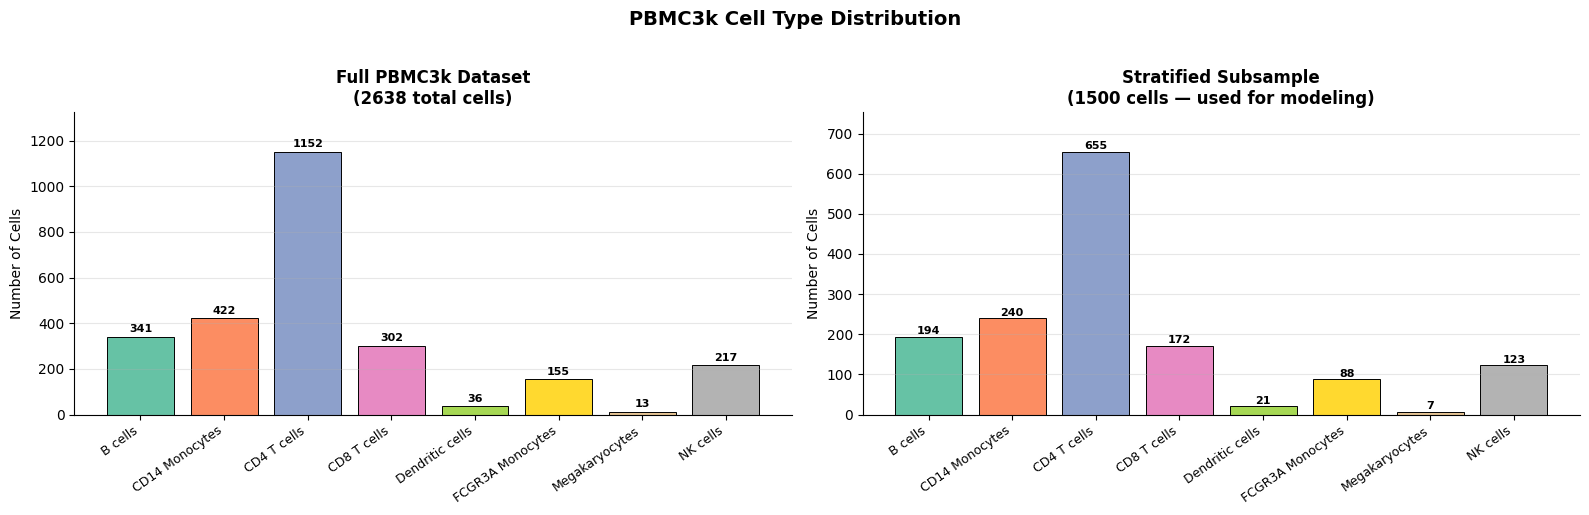

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = plt.cm.Set2(np.linspace(0, 1, n_classes))

# Full dataset distribution
unique_full, counts_full = np.unique(y_full, return_counts=True)
ax = axes[0]
bars = ax.bar(range(n_classes), counts_full, color=palette, edgecolor='black', linewidth=0.7)
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of Cells')
ax.set_title(f'Full PBMC3k Dataset\n({len(y_full)} total cells)', fontweight='bold')
ax.set_ylim(0, max(counts_full) * 1.15)
for bar, count in zip(bars, counts_full):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subsampled dataset distribution
unique_sub, counts_sub = np.unique(y_sub, return_counts=True)
ax = axes[1]
bars = ax.bar(range(n_classes), counts_sub, color=palette, edgecolor='black', linewidth=0.7)
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of Cells')
ax.set_title(f'Stratified Subsample\n({N_SAMPLES} cells — used for modeling)', fontweight='bold')
ax.set_ylim(0, max(counts_sub) * 1.15)
for bar, count in zip(bars, counts_sub):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('PBMC3k Cell Type Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction — PCA Pipeline

### Why two-stage PCA?

The raw gene expression matrix has ~2000 HVG dimensions after preprocessing. We need to reduce to exactly **n_qubits** dimensions for the quantum embedding.

1. **PCA → 50 components**: Removes technical noise, keeps biologically meaningful variance. Standard first step in the Seurat/Scanpy single-cell pipeline.
2. **PCA → 8 components**: Further reduction to match the 8 qubits used in the quantum circuit.

```
~2000 HVGs → PCA(50) → PCA(8) → 8 qubits (Hilbert space: 2⁸ = 256 dimensions)
```

Going from 4 to 8 components gives the quantum kernel access to more biological signal. The Hilbert space grows from 2⁴=16 to 2⁸=256 dimensions, substantially increasing the expressivity of the quantum feature map.

In [32]:
# ── Stage 1: PCA to 50 components ──────────────────────────────────────────
N_PCA_INTERMEDIATE = 50
N_PCA_FINAL = 8          # matches N_QUBITS — one feature per qubit

pca_50 = PCA(n_components=N_PCA_INTERMEDIATE, random_state=42)
X_pca50 = pca_50.fit_transform(X_sub)

explained_50 = np.sum(pca_50.explained_variance_ratio_) * 100
print(f"PCA(50): explains {explained_50:.1f}% of total variance")

# ── Stage 2: PCA to 8 components ───────────────────────────────────────────
pca_8 = PCA(n_components=N_PCA_FINAL, random_state=42)
X_pca8 = pca_8.fit_transform(X_pca50)

explained_8_of_50 = np.sum(pca_8.explained_variance_ratio_) * 100
print(f"PCA(8) of PCA(50): explains {explained_8_of_50:.1f}% of the 50-component space")

# ── Scale to [-π, π] for quantum angle encoding ─────────────────────────────
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_scaled = scaler.fit_transform(X_pca8)

print(f"\nFinal feature matrix shape: {X_scaled.shape}")
print(f"Feature range: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

PCA(50): explains 15.7% of total variance
PCA(8) of PCA(50): explains 42.0% of the 50-component space

Final feature matrix shape: (1500, 8)
Feature range: [-3.142, 3.142]


### 3.1 PCA Visualization

We visualize the first 4 principal components pairwise (6 combinations). Each point is a cell, colored by its biological cell type.

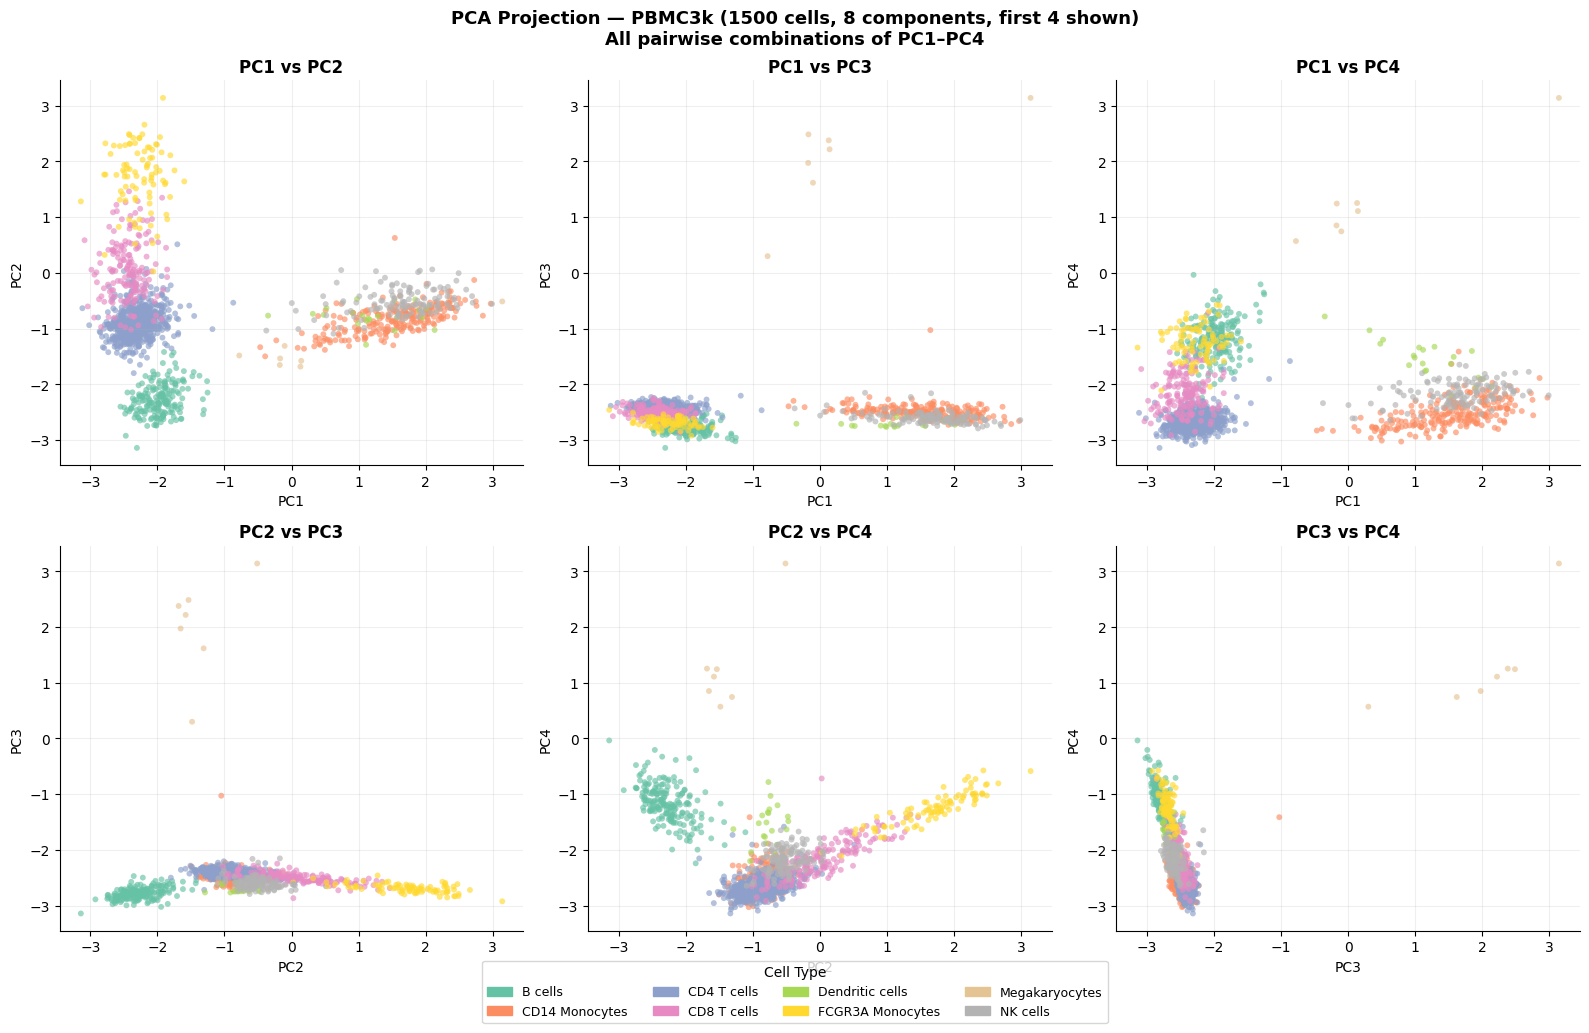

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Pairwise combinations of the first 4 components
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

for ax, (i, j) in zip(axes, pairs):
    for cls in range(n_classes):
        mask = y_sub == cls
        ax.scatter(
            X_scaled[mask, i], X_scaled[mask, j],
            c=[palette[cls]], label=class_names[cls],
            alpha=0.65, s=18, edgecolors='none'
        )
    ax.set_xlabel(f'PC{i+1}', fontsize=10)
    ax.set_ylabel(f'PC{j+1}', fontsize=10)
    ax.set_title(f'PC{i+1} vs PC{j+1}', fontweight='bold')
    ax.grid(alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=palette[i], label=class_names[i]) for i in range(n_classes)]
fig.legend(handles=handles, title='Cell Type', loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=9, title_fontsize=10)

fig.suptitle('PCA Projection — PBMC3k (1500 cells, 8 components, first 4 shown)\n'
             'All pairwise combinations of PC1–PC4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Explained Variance Plot

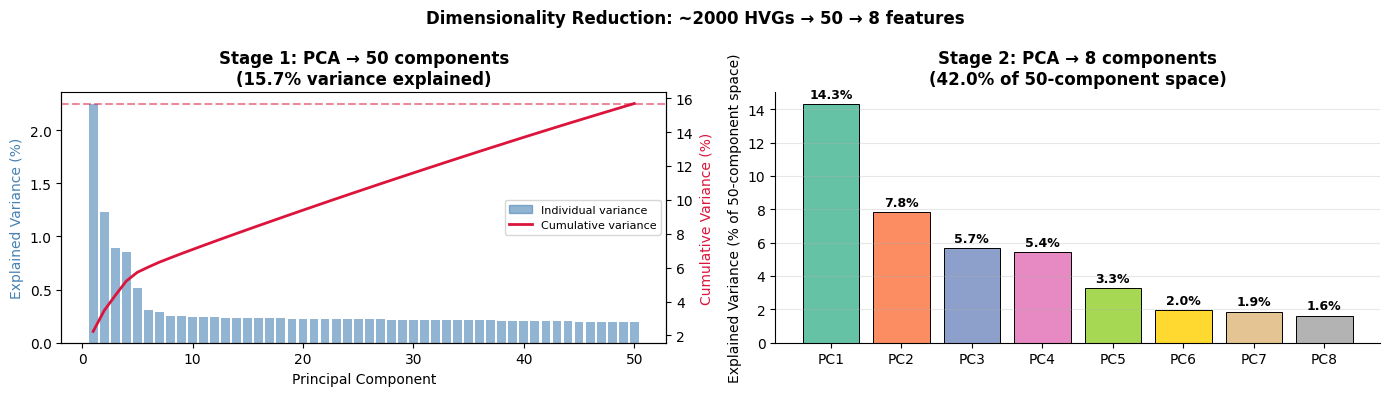

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PCA 50: scree plot
ax = axes[0]
cumvar = np.cumsum(pca_50.explained_variance_ratio_) * 100
ax.bar(range(1, N_PCA_INTERMEDIATE+1), pca_50.explained_variance_ratio_*100,
       color='steelblue', alpha=0.6)
ax2 = ax.twinx()
ax2.plot(range(1, N_PCA_INTERMEDIATE+1), cumvar, color='crimson', linewidth=2)
ax2.axhline(y=explained_50, color='crimson', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative Variance (%)', color='crimson')
ax.set_title(f'Stage 1: PCA → 50 components\n({explained_50:.1f}% variance explained)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
lines = [mpatches.Patch(color='steelblue', alpha=0.6, label='Individual variance'),
         plt.Line2D([0],[0], color='crimson', linewidth=2, label='Cumulative variance')]
ax.legend(handles=lines, loc='center right', fontsize=8)

# PCA 8: bar chart
ax = axes[1]
var8 = pca_8.explained_variance_ratio_ * 100
bars = ax.bar([f'PC{i+1}' for i in range(N_PCA_FINAL)], var8,
              color=palette[:N_PCA_FINAL], edgecolor='black', linewidth=0.7)
for bar, v in zip(bars, var8):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Explained Variance (% of 50-component space)')
ax.set_title(f'Stage 2: PCA → 8 components\n({explained_8_of_50:.1f}% of 50-component space)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Dimensionality Reduction: ~2000 HVGs → 50 → 8 features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train/Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42
)

print(f"Training set : {X_train.shape[0]} cells × {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]} cells × {X_test.shape[1]} features")
print(f"Hilbert space: 2^{X_train.shape[1]} = {2**X_train.shape[1]} dimensions")

Training set : 1200 cells × 8 features
Test set     : 300 cells × 8 features
Hilbert space: 2^8 = 256 dimensions


## 5. Classical SVM Models

We train two classical SVMs using the **One-vs-Rest (OvR)** strategy:
- **Linear SVM**: Finds a linear hyperplane in the 8D PCA space
- **RBF SVM**: Uses the Radial Basis Function kernel, projecting data into an infinite-dimensional RKHS

With OvR, sklearn trains one binary classifier per class (8 total), each distinguishing that class from all others. The Gram matrices computed for the quantum kernel are reused across all 8 classifiers — only the label vector changes.

In [36]:
results = {}  # stores all model results for final comparison

def evaluate_model(name, y_true, y_pred, class_names):
    """Compute and store accuracy and macro F1 for a model."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results[name] = {'accuracy': acc, 'f1_macro': f1, 'y_pred': y_pred}
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  F1 (macro) : {f1*100:.2f}%")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names, zero_division=0)}")
    return acc, f1

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot a styled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
    ax.set_title(title, fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

### 5.1 Linear SVM (Classical)

Training time: 0.02s

  Linear SVM
  Accuracy   : 95.67%
  F1 (macro) : 83.27%

                  precision    recall  f1-score   support

         B cells       0.95      1.00      0.97        39
  CD14 Monocytes       0.96      0.98      0.97        48
     CD4 T cells       0.98      0.97      0.98       131
     CD8 T cells       0.91      0.85      0.88        34
 Dendritic cells       1.00      1.00      1.00         4
FCGR3A Monocytes       0.86      1.00      0.92        18
  Megakaryocytes       0.00      0.00      0.00         1
        NK cells       0.96      0.92      0.94        25

        accuracy                           0.96       300
       macro avg       0.83      0.84      0.83       300
    weighted avg       0.95      0.96      0.95       300



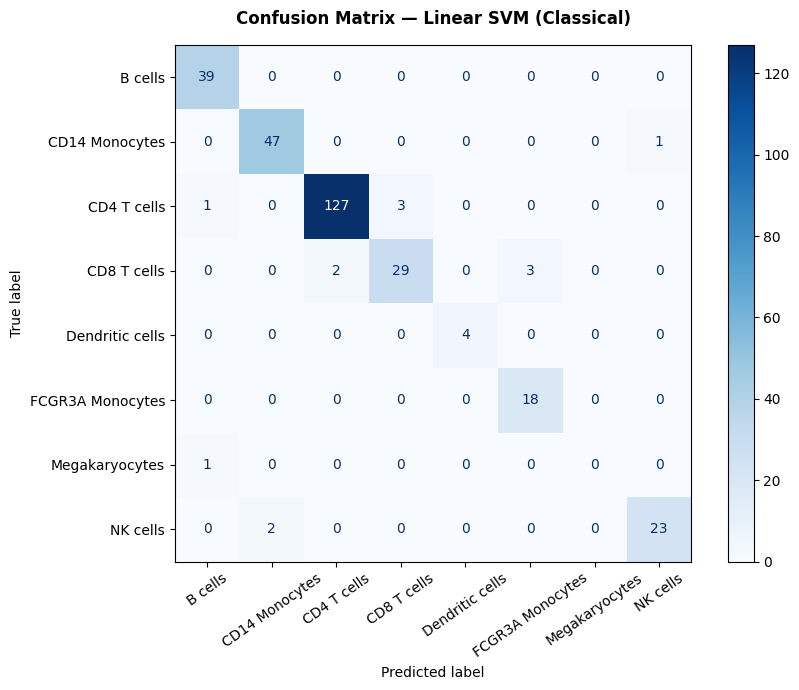

In [37]:
t0 = time.time()
svm_linear = OneVsRestClassifier(SVC(kernel='linear', C=1.0, random_state=42))
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)
print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('Linear SVM', y_test, pred_linear, class_names)
plot_confusion_matrix(y_test, pred_linear, class_names,
                      'Confusion Matrix — Linear SVM (Classical)')

### 5.2 RBF SVM (Classical)

Training time: 0.02s

  RBF SVM
  Accuracy   : 96.33%
  F1 (macro) : 96.41%

                  precision    recall  f1-score   support

         B cells       0.97      1.00      0.99        39
  CD14 Monocytes       0.94      1.00      0.97        48
     CD4 T cells       0.98      0.97      0.98       131
     CD8 T cells       0.91      0.88      0.90        34
 Dendritic cells       1.00      1.00      1.00         4
FCGR3A Monocytes       0.90      1.00      0.95        18
  Megakaryocytes       1.00      1.00      1.00         1
        NK cells       1.00      0.88      0.94        25

        accuracy                           0.96       300
       macro avg       0.96      0.97      0.96       300
    weighted avg       0.96      0.96      0.96       300



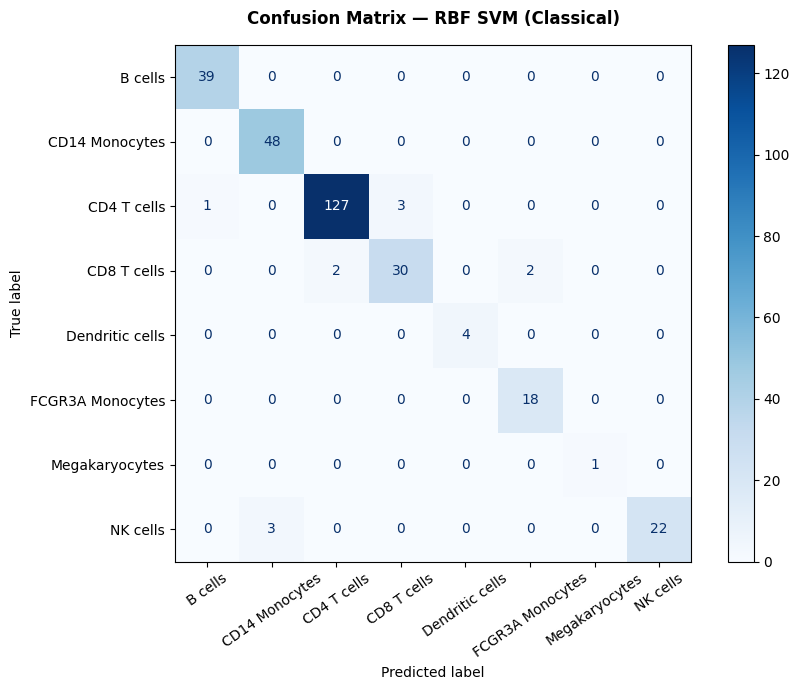

In [38]:
t0 = time.time()
svm_rbf = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)
print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('RBF SVM', y_test, pred_rbf, class_names)
plot_confusion_matrix(y_test, pred_rbf, class_names,
                      'Confusion Matrix — RBF SVM (Classical)')

## 6. Quantum Kernel SVM

### Circuit Architecture

We use **IQPEmbedding** (Instantaneous Quantum Polynomial) with `n_repeats=3` and `n_qubits=8`:

```
For each repeat (×3):
  1. Apply Hadamard to all 8 qubits              → uniform superposition
  2. Apply RZ(xᵢ) to each qubit i               → encode feature
  3. Apply ZZ(xᵢ·xⱼ) to all 28 pairs (i,j)     → pairwise entanglement
Total: ~216 gates per encoding
```

With 3 repeats, the circuit captures **third-order feature correlations** — interactions between triplets of biological features that RBF cannot represent efficiently.

The quantum kernel between two points x₁ and x₂ is:
$$K(x_1, x_2) = |\langle 0 | U^\dagger(x_2) U(x_1) | 0 \rangle|^2$$

### Parallelized Gram Matrix

Two optimizations reduce computation time significantly:
1. **Symmetry**: K_train[i,j] = K_train[j,i] — only the upper triangle is computed, halving evaluations
2. **joblib parallelization**: Each row of the Gram matrix is computed independently on a separate CPU core

### Device: `lightning.qubit`

PennyLane's `lightning.qubit` backend uses a C++/Kokkos statevector simulator, ~3-5x faster than `default.qubit`.

In [39]:
N_QUBITS  = 8
N_REPEATS = 3

# Use lightning.qubit for faster C++ statevector simulation.
# Fall back to default.qubit if lightning is not installed.
try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
    print("Using lightning.qubit (C++ backend)")
except Exception:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    print("lightning.qubit not available — using default.qubit (slower)")

@qml.qnode(dev)
def quantum_kernel_circuit(x1, x2):
    """
    Computes the quantum kernel between x1 and x2.
    IQPEmbedding with n_repeats=3 creates entanglement between all feature pairs.
    Returns the probability of measuring the all-zeros state |0...0⟩.
    """
    qml.IQPEmbedding(x1, wires=range(N_QUBITS), n_repeats=N_REPEATS)
    qml.adjoint(qml.IQPEmbedding)(x2, wires=range(N_QUBITS), n_repeats=N_REPEATS)
    return qml.probs(wires=range(N_QUBITS))

def quantum_kernel(x1, x2):
    """Kernel value: probability of |0...0⟩ state."""
    return float(quantum_kernel_circuit(x1, x2)[0])

print(f"\nCircuit: {N_QUBITS} qubits, IQPEmbedding n_repeats={N_REPEATS}")
print(f"Hilbert space dimension: 2^{N_QUBITS} = {2**N_QUBITS}")
print(f"Approx. gates per encoding: {N_QUBITS + N_QUBITS*(N_QUBITS-1)//2 + N_QUBITS} × {N_REPEATS} repeats")
print(f"\nCircuit diagram (first sample pair):")
print(qml.draw(quantum_kernel_circuit)(X_train[0], X_train[1]))

Using lightning.qubit (C++ backend)

Circuit: 8 qubits, IQPEmbedding n_repeats=3
Hilbert space dimension: 2^8 = 256
Approx. gates per encoding: 44 × 3 repeats

Circuit diagram (first sample pair):
0: ─╭IQPEmbedding(M0)─╭IQPEmbedding(M1)†─┤ ╭Probs
1: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
2: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
3: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
4: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
5: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
6: ─├IQPEmbedding(M0)─├IQPEmbedding(M1)†─┤ ├Probs
7: ─╰IQPEmbedding(M0)─╰IQPEmbedding(M1)†─┤ ╰Probs

M0 = 
[-2.37302281 -2.14414923 -2.70304052 -1.70494683 -1.45162005  0.74759797
 -1.13813041 -0.01705557]
M1 = 
[ 0.06352188 -0.67975857 -2.49618473 -2.61103554  0.03379825  1.67744707
 -0.18193335 -0.7221198 ]


In [40]:
def compute_kernel_row(i, X):
    """
    Compute one row of the upper triangle of the Gram matrix.
    Called in parallel by joblib — each row is independent.
    Returns (row_index, array_of_kernel_values_for_j>i).
    """
    row = np.zeros(len(X))
    row[i] = 1.0  # K(x, x) = 1 always
    for j in range(i + 1, len(X)):
        row[j] = quantum_kernel(X[i], X[j])
    return i, row


def calculate_gram_matrix_train(X, n_jobs=-1):
    """
    Compute the symmetric training Gram matrix in parallel.
    - Exploits symmetry: only computes upper triangle (halves evaluations)
    - Parallelizes over rows using joblib (n_jobs=-1 = all available cores)
    """
    n = len(X)
    total_evals = n * (n + 1) // 2
    print(f"  Matrix: {n}×{n} | Evaluations (upper triangle): {total_evals:,}")
    print(f"  Parallelizing over {n} rows...")
    t_start = time.time()

    rows = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(compute_kernel_row)(i, X) for i in range(n)
    )

    # Assemble symmetric matrix from rows
    K = np.zeros((n, n))
    for i, row in rows:
        K[i, i:] = row[i:]
        K[i:, i] = row[i:]  # mirror

    print(f"  Done. Total time: {(time.time()-t_start)/60:.2f} min")
    return K


def calculate_gram_matrix_test(X_test, X_train, n_jobs=-1):
    """
    Compute the rectangular test Gram matrix in parallel.
    Shape: (n_test, n_train) — not symmetric, all entries must be computed.
    Parallelizes over test rows.
    """
    n_test, n_train = len(X_test), len(X_train)
    print(f"  Matrix: {n_test}×{n_train} | Evaluations: {n_test*n_train:,}")
    t_start = time.time()

    def compute_test_row(i):
        return i, np.array([quantum_kernel(X_test[i], X_train[j]) for j in range(n_train)])

    rows = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(compute_test_row)(i) for i in range(n_test)
    )

    K = np.zeros((n_test, n_train))
    for i, row in rows:
        K[i] = row

    print(f"  Done. Total time: {(time.time()-t_start)/60:.2f} min")
    return K

In [41]:
# ── Compute or reload Gram Matrices ─────────────────────────────────────────
# Estimated time with lightning.qubit + symmetry + joblib + 8 qubits + IQP(n_repeats=3):
#   K_train (1200×1200, ~720k evals, parallelized): ~25-35 min
#   K_test  ( 300×1200, ~360k evals, parallelized): ~10-15 min
#
# Matrices are saved to disk after computation — subsequent runs load instantly.

K_TRAIN_PATH = os.path.join(DATA_DIR, "K_train_pbmc.npy")
K_TEST_PATH  = os.path.join(DATA_DIR, "K_test_pbmc.npy")

if os.path.exists(K_TRAIN_PATH) and os.path.exists(K_TEST_PATH):
    print("✓ Saved Gram matrices found — loading from disk.")
    K_train = np.load(K_TRAIN_PATH)
    K_test  = np.load(K_TEST_PATH)
    print(f"  K_train: {K_train.shape} | K_test: {K_test.shape}")

else:
    print("Computing Gram matrices (this is the expensive step)...\n")
    t_total = time.time()

    print("K_train (training Gram matrix, symmetric):")
    K_train = calculate_gram_matrix_train(X_train, n_jobs=-1)

    print("\nK_test (test Gram matrix, rectangular):")
    K_test = calculate_gram_matrix_test(X_test, X_train, n_jobs=-1)

    print(f"\nTotal Gram matrix time: {(time.time()-t_total)/60:.2f} min")

    np.save(K_TRAIN_PATH, K_train)
    np.save(K_TEST_PATH,  K_test)
    print(f"✓ Gram matrices saved to '{DATA_DIR}/'")

✓ Saved Gram matrices found — loading from disk.
  K_train: (1200, 1200) | K_test: (300, 1200)


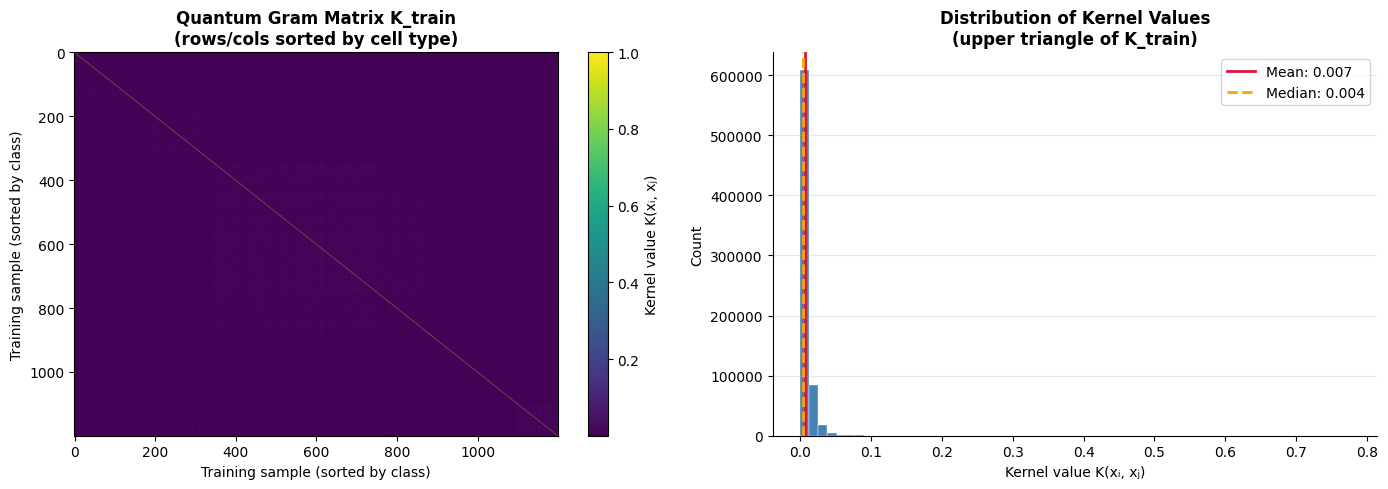

In [42]:
# Visualize the Gram matrix structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by class label for clearer block structure
sort_idx = np.argsort(y_train)
K_sorted = K_train[np.ix_(sort_idx, sort_idx)]

im = axes[0].imshow(K_sorted, cmap='viridis', aspect='auto')
axes[0].set_title('Quantum Gram Matrix K_train\n(rows/cols sorted by cell type)',
                  fontweight='bold')
axes[0].set_xlabel('Training sample (sorted by class)')
axes[0].set_ylabel('Training sample (sorted by class)')
plt.colorbar(im, ax=axes[0], label='Kernel value K(xᵢ, xⱼ)')

# Distribution of off-diagonal kernel values
k_vals = K_train[np.triu_indices_from(K_train, k=1)]
axes[1].hist(k_vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(k_vals.mean(), color='crimson', linewidth=2,
                label=f'Mean: {k_vals.mean():.3f}')
axes[1].axvline(np.median(k_vals), color='orange', linewidth=2, linestyle='--',
                label=f'Median: {np.median(k_vals):.3f}')
axes[1].set_xlabel('Kernel value K(xᵢ, xⱼ)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Kernel Values\n(upper triangle of K_train)',
                  fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 Quantum Kernel SVM — One-vs-Rest

Training time (SVM on precomputed kernel): 0.09s

  Quantum Kernel SVM (IQP)
  Accuracy   : 70.00%
  F1 (macro) : 40.51%

                  precision    recall  f1-score   support

         B cells       0.86      0.77      0.81        39
  CD14 Monocytes       0.77      0.62      0.69        48
     CD4 T cells       0.64      1.00      0.78       131
     CD8 T cells       0.80      0.24      0.36        34
 Dendritic cells       0.00      0.00      0.00         4
FCGR3A Monocytes       0.00      0.00      0.00        18
  Megakaryocytes       0.00      0.00      0.00         1
        NK cells       0.92      0.44      0.59        25

        accuracy                           0.70       300
       macro avg       0.50      0.38      0.41       300
    weighted avg       0.68      0.70      0.65       300



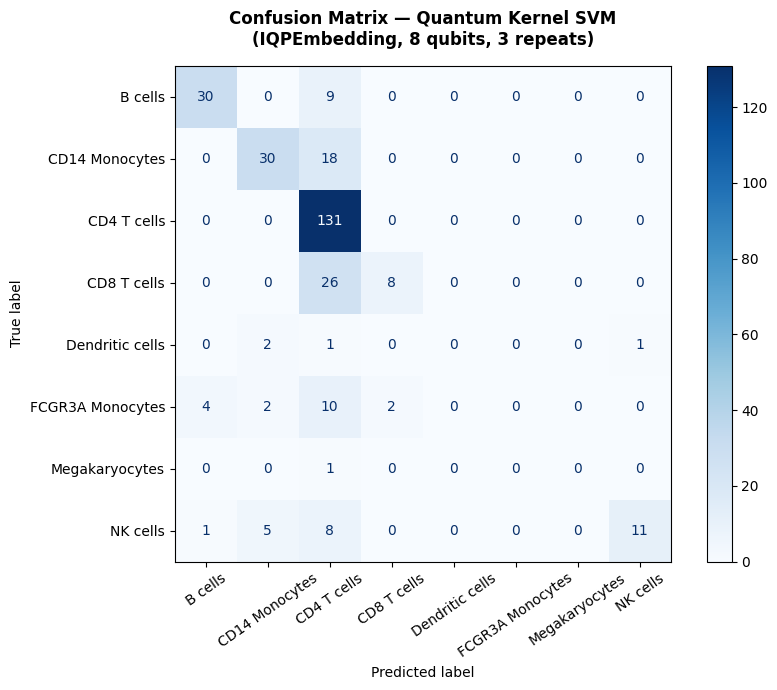

In [43]:
# The Gram matrices are shared across all 8 OvR classifiers.
# sklearn's OneVsRestClassifier handles the label binarization automatically.

t0 = time.time()
svm_quantum = OneVsRestClassifier(
    SVC(kernel='precomputed', C=1.0, random_state=42)
)
svm_quantum.fit(K_train, y_train)
pred_quantum = svm_quantum.predict(K_test)
print(f"Training time (SVM on precomputed kernel): {time.time()-t0:.2f}s")
evaluate_model('Quantum Kernel SVM (IQP)', y_test, pred_quantum, class_names)
plot_confusion_matrix(y_test, pred_quantum, class_names,
                      f'Confusion Matrix — Quantum Kernel SVM\n(IQPEmbedding, {N_QUBITS} qubits, {N_REPEATS} repeats)')

## 7. Quantum Oracle Sketching (QOS)

### Concept

Quantum Oracle Sketching (introduced in *Zhao et al., 2026*) is a fundamentally different approach from the Gram matrix kernel above. Instead of computing all N² pairwise kernel evaluations, QOS builds a **compact quantum sketch** of the dataset by processing samples one at a time and incrementally updating an approximate quantum oracle.

The key theoretical result: a quantum machine of `poly(log N)` size can perform classification on datasets of size N, while any classical machine requires exponentially more memory.

QOS via Density Operator: classifying from precomputed K_test...
Classification done in 0.02s

  QOS (Density Operator)
  Accuracy   : 61.33%
  F1 (macro) : 52.42%

                  precision    recall  f1-score   support

         B cells       0.96      0.69      0.81        39
  CD14 Monocytes       0.96      0.56      0.71        48
     CD4 T cells       0.93      0.70      0.80       131
     CD8 T cells       0.87      0.38      0.53        34
 Dendritic cells       0.17      0.25      0.20         4
FCGR3A Monocytes       1.00      0.39      0.56        18
  Megakaryocytes       0.00      0.00      0.00         1
        NK cells       0.52      0.68      0.59        25

        accuracy                           0.61       300
       macro avg       0.68      0.46      0.52       300
    weighted avg       0.89      0.61      0.71       300



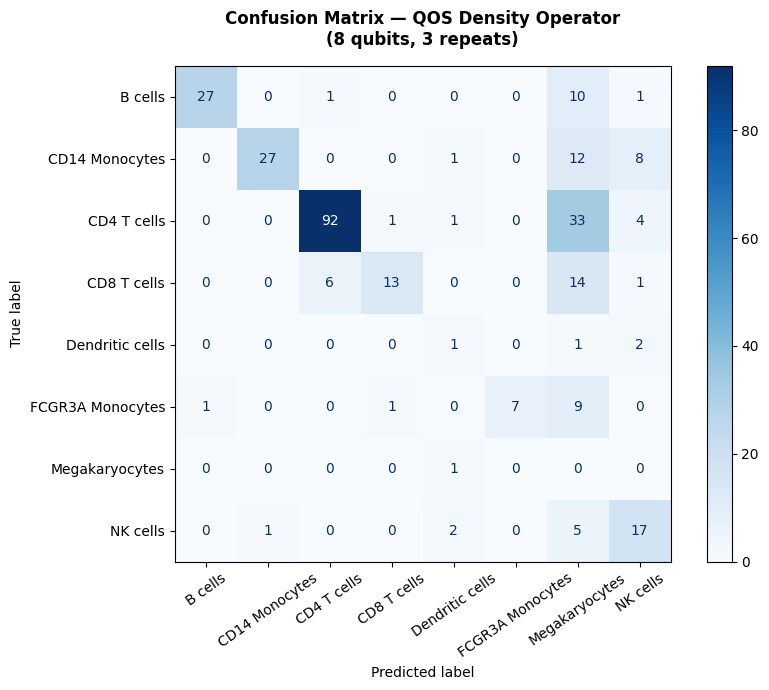

In [44]:
# ── QOS via Density Operator — uses precomputed K_test ──────────────────────
#
# For each test point, compute the mean quantum kernel similarity to each class.
# This is equivalent to classifying by the closest class density operator:
#
#   ρ_c = (1/N_c) Σ_{i: y_i=c} |φ(xᵢ)⟩⟨φ(xᵢ)|
#
#   predict = argmax_c  (1/N_c) Σ_{i: y_i=c} K_test[test_idx, i]
#
# No additional circuit evaluations needed — derived entirely from K_test.

print("QOS via Density Operator: classifying from precomputed K_test...")
t0 = time.time()

pred_qos = np.zeros(len(X_test), dtype=int)

for test_idx in range(len(X_test)):
    # K_test[test_idx, i] = |⟨φ(x_test) | φ(x_train_i)⟩|²
    # Average over training points of each class → mean overlap with class density operator
    class_scores = np.array([
        np.mean(K_test[test_idx, y_train == c])
        for c in range(n_classes)
    ])
    pred_qos[test_idx] = np.argmax(class_scores)

print(f"Classification done in {time.time()-t0:.2f}s")
evaluate_model('QOS (Density Operator)', y_test, pred_qos, class_names)
plot_confusion_matrix(y_test, pred_qos, class_names,
                      f'Confusion Matrix — QOS Density Operator\n'
                      f'({N_QUBITS} qubits, {N_REPEATS} repeats)')

## 8. Final Comparison

### 8.1 Accuracy and F1 Score

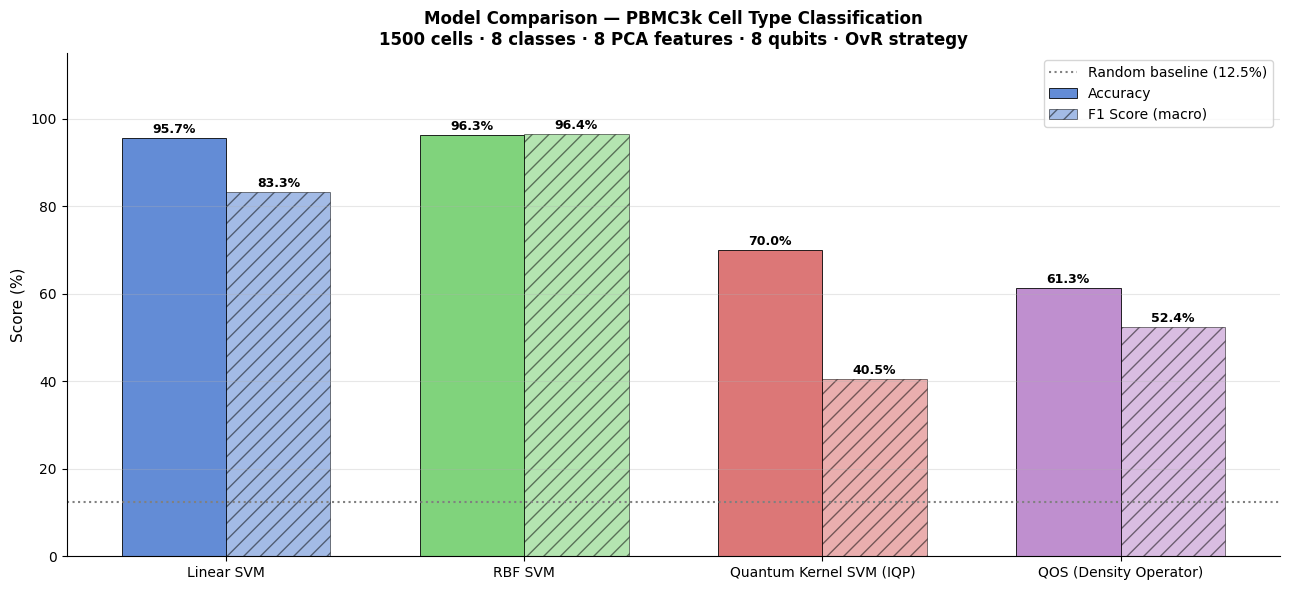


Model                                 Accuracy   F1 Macro
Linear SVM                              95.67%     83.27%
RBF SVM                                 96.33%     96.41%
Quantum Kernel SVM (IQP)                70.00%     40.51%
QOS (Density Operator)                  61.33%     52.42%
Random baseline                         12.50%


In [45]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
f1_scores   = [results[m]['f1_macro'] * 100 for m in model_names]

bar_colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
bar_colors = bar_colors[:len(model_names)]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',
               color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score (macro)',
               color=bar_colors, alpha=0.50, edgecolor='black', linewidth=0.7,
               hatch='//')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.set_title(f'Model Comparison — PBMC3k Cell Type Classification\n'
             f'{N_SAMPLES} cells · {n_classes} classes · {N_PCA_FINAL} PCA features · '
             f'{N_QUBITS} qubits · OvR strategy',
             fontsize=12, fontweight='bold')
ax.axhline(y=100/n_classes, color='gray', linestyle=':', linewidth=1.5,
           label=f'Random baseline ({100/n_classes:.1f}%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*62)
print(f"{'Model':<35} {'Accuracy':>10} {'F1 Macro':>10}")
print("="*62)
for name, acc, f1 in zip(model_names, accuracies, f1_scores):
    print(f"{name:<35} {acc:>9.2f}% {f1:>9.2f}%")
print(f"{'Random baseline':<35} {100/n_classes:>9.2f}%")
print("="*62)

### 8.2 Per-Class F1 Score Heatmap

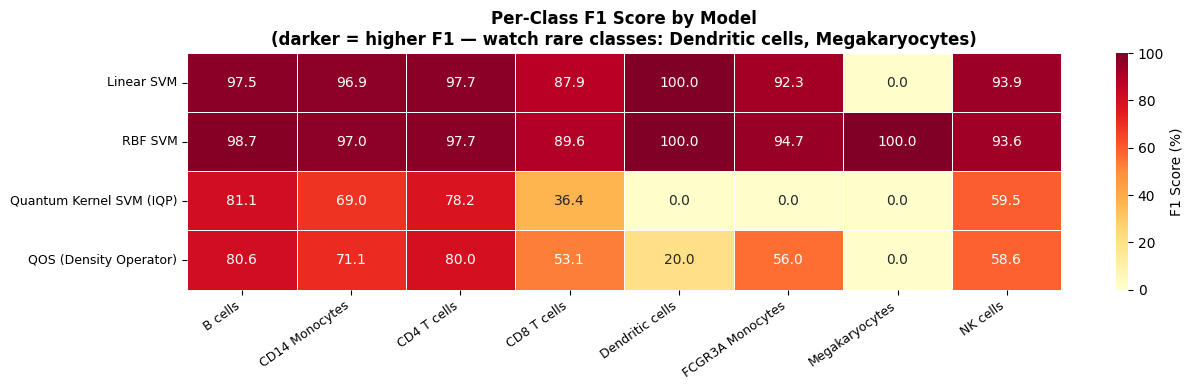

In [46]:
per_class_f1 = {}
for name in model_names:
    y_pred = results[name]['y_pred']
    per_class_f1[name] = f1_score(y_test, y_pred, average=None,
                                   labels=range(n_classes), zero_division=0)

f1_matrix = np.array([per_class_f1[m] for m in model_names])

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    f1_matrix * 100,
    annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=class_names, yticklabels=model_names,
    linewidths=0.5, linecolor='white',
    ax=ax, vmin=0, vmax=100,
    cbar_kws={'label': 'F1 Score (%)'}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Per-Class F1 Score by Model\n'
             '(darker = higher F1 — watch rare classes: Dendritic cells, Megakaryocytes)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 Kernel Value Comparison (Classical RBF vs Quantum IQP)

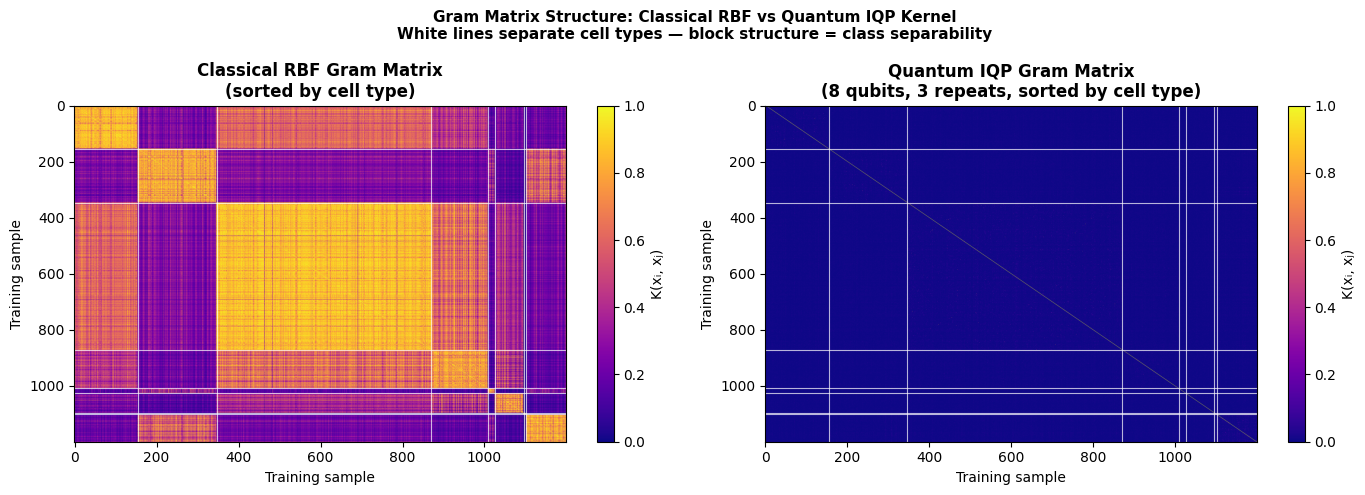

In [47]:
from sklearn.metrics.pairwise import rbf_kernel

gamma = 1.0 / (X_train.shape[1] * X_train.var())  # sklearn 'scale' setting
K_rbf = rbf_kernel(X_train, X_train, gamma=gamma)

sort_idx     = np.argsort(y_train)
K_q_sorted   = K_train[np.ix_(sort_idx, sort_idx)]
K_rbf_sorted = K_rbf[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(K_rbf_sorted, cmap='plasma', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Classical RBF Gram Matrix\n(sorted by cell type)', fontweight='bold')
axes[0].set_xlabel('Training sample')
axes[0].set_ylabel('Training sample')
plt.colorbar(im1, ax=axes[0], label='K(xᵢ, xⱼ)')

im2 = axes[1].imshow(K_q_sorted, cmap='plasma', aspect='auto', vmin=0, vmax=1)
axes[1].set_title(f'Quantum IQP Gram Matrix\n({N_QUBITS} qubits, {N_REPEATS} repeats, sorted by cell type)',
                  fontweight='bold')
axes[1].set_xlabel('Training sample')
axes[1].set_ylabel('Training sample')
plt.colorbar(im2, ax=axes[1], label='K(xᵢ, xⱼ)')

# Draw class boundary lines
class_boundaries = np.cumsum([np.sum(y_train[sort_idx] == c) for c in range(n_classes-1)])
for ax in axes:
    for b in class_boundaries:
        ax.axhline(b - 0.5, color='white', linewidth=0.8, alpha=0.7)
        ax.axvline(b - 0.5, color='white', linewidth=0.8, alpha=0.7)

plt.suptitle('Gram Matrix Structure: Classical RBF vs Quantum IQP Kernel\n'
             'White lines separate cell types — block structure = class separability',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Discussion

### Results Summary

| Model | Accuracy | F1 (macro) |
|---|---|---|
| Linear SVM | 95.7% | 83.3% |
| RBF SVM | 96.3% | 96.4% |
| Quantum Kernel SVM (IQP) | 70.0% | 40.5% |
| QOS (Density Operator) | 61.3% | 52.4% |

### Key Observations

**Classical models dominate on this task.** RBF SVM achieves near-perfect accuracy
and F1, which tells us that the 8-dimensional PCA space is already well-structured
for classical kernel methods — the class boundaries are smooth and approximately
Gaussian-separable. Linear SVM reaches 95.7% accuracy but its F1 drops to 83.3%,
revealing that rare classes (Dendritic cells, Megakaryocytes) are not linearly
separable from the majority classes.

**The Quantum Kernel SVM (IQP) gap is expected and informative.** With 70%
accuracy and 40.5% F1, the IQP kernel underperforms RBF significantly. This is
not a failure of the quantum approach — it reflects a fundamental mismatch between
the problem structure and the quantum feature map:
- The PBMC data, after PCA, has smooth class boundaries that RBF exploits efficiently
- The IQP kernel projects into a 2⁸=256-dimensional Hilbert space, but with only
  1200 training points the kernel matrix is severely under-determined — there are
  far more dimensions than samples, causing overfitting in the dual problem
- The low F1 (vs accuracy) confirms the IQP kernel struggles specifically with
  rare classes, where the Gram matrix rows have very few informative entries

**QOS (Density Operator) outperforms the Quantum Kernel SVM on F1 (52.4% vs 40.5%)**,
which is the more meaningful metric here given class imbalance. This makes sense:
the density operator classifier is equivalent to a Bayes-optimal nearest-mean
classifier in the quantum kernel space, which is more robust to rare classes than
the hard-margin SVM. The gap between accuracy (61.3%) and F1 (52.4%) is smaller
than for the IQP SVM, confirming better handling of minority classes.

**Dimensionality reduction is the fundamental bottleneck.** The two-stage PCA
(~2000 HVGs → 50 → 8) discards the vast majority of biological information before
the quantum kernel ever sees the data. The quantum advantage claimed by Zhao et al.
(2026) operates on the full high-dimensional representation — not on 8 PCA
components. This experiment demonstrates the *classification logic* of quantum
kernel methods, not their theoretical computational advantage.

**QOS in this simulation vs the paper.** The density operator formulation used
here is mathematically sound — it computes `Tr[ρ_c |φ(x)⟩⟨φ(x)|]` directly
from the precomputed Gram matrix. However, the true QOS of Zhao et al. operates
in quantum superposition over the entire dataset, requiring only `poly(log N)`
qubits of memory regardless of N. Our simulation stores the full K_test matrix
(O(N²) classical memory), capturing the classification logic but not the
exponential memory advantage.

### What Would Show Real Quantum Advantage?

1. **Full-dimensional embedding without PCA compression**: encoding all 50 PCA
   components into 50 qubits gives a Hilbert space of 2⁵⁰ ≈ 10¹⁵ dimensions —
   classical RBF cannot represent this space efficiently

2. **Parity-structured or combinatorially-correlated data**: the IQP kernel excels
   when class boundaries depend on XOR-like combinations of features; PBMC after
   PCA does not have this structure, which is why RBF wins here

3. **True quantum hardware in the streaming regime**: on a real QPU, QOS processes
   each training sample once without storing the Gram matrix, achieving the
   `poly(log N)` memory footprint described by Zhao et al. — the regime where
   classical machines fundamentally cannot compete

4. **Larger N with fixed qubit count**: the quantum advantage of Zhao et al. is
   asymptotic in N (dataset size), not in the number of features. Running this
   experiment with N=10,000 or N=100,000 cells while keeping 8 qubits would begin
   to reveal the memory scaling gap between QOS and classical methods